# Call Density Estimatation of Burrowing Owls

Inspired by:
https://github.com/google-research/perch/blob/75fdf0f6ae4055e68dd5037b29a872fc5edcf3f3/chirp/inference/call_density.py#L203

In [2]:
import pandas as pd

df = pd.read_csv("results/all_model_redictions_96545a6b81b24794962d464e8fcbdc1d.csv")

# Step 1) Get P(z)

<Axes: >

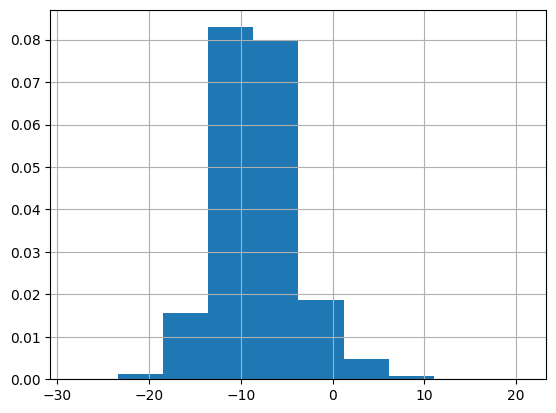

In [3]:
# This would be P(z) in the paper

df["alarm"].hist(density=True)

# Step 2) Identify Log bins and thier probabilities

In [4]:
# Apply log bins for k=4
bins = []
bin_prob = [0.5, 0.25, 0.125, 0.125] # basically come naturally from quartiles
for i in [0, 0.5, 0.75, 0.75 + 0.125, 1]:
    bins.append(df["alarm"].quantile(i))
df["alarm_log_bins"] = pd.cut(df["alarm"], bins)

# Step 3) Verify each example

In [5]:
to_verify_examples = df.groupby(by="alarm_log_bins").sample(25)
to_verify_examples

/tmp/ipykernel_2812524/559746205.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  to_verify_examples = df.groupby(by="alarm_log_bins").sample(25)


,Unnamed: 0,file_path,offset,confidence,pred_label,cluck,coocoo,twitter,alarm,chick_begging,alarm_log_bins
1854329,1854329,/mnt/restorage/Audiomoth/Raw sound files/2024/...,4449,1.000000,no_buow,-26.750640,-22.284258,-23.166813,-14.390218,-21.095438,"(-28.257, -8.527]"
510110,510110,/mnt/restorage/Audiomoth/Raw sound files/2024/...,61536,1.000000,no_buow,-30.549124,-28.812480,-30.087538,-19.195610,-24.282470,"(-28.257, -8.527]"
347678,347678,/mnt/restorage/Audiomoth/Raw sound files/2024/...,6237,1.000000,no_buow,-20.310467,-20.719234,-14.046065,-8.650849,-16.428015,"(-28.257, -8.527]"
1153053,1153053,/mnt/restorage/Audiomoth/Raw sound files/2024/...,4989,1.000000,no_buow,-23.854769,-21.806376,-18.688698,-10.056079,-17.907070,"(-28.257, -8.527]"
1812754,1812754,/mnt/restorage/Audiomoth/Raw sound files/2024/...,33234,1.000000,no_buow,-15.965999,-16.857780,-13.575439,-8.667434,-10.945729,"(-28.257, -8.527]"
...,...,...,...,...,...,...,...,...,...,...,...
2709343,2709343,/mnt/restorage/Audiomoth/Raw sound files/2024/...,61659,0.645446,alarm,-8.822300,-12.920932,-12.660429,-2.318952,-4.045837,"(-3.863, 20.842]"
2180592,2180592,/mnt/restorage/Audiomoth/Raw sound files/2024/...,234,0.999842,no_buow,-14.832862,-18.991100,-14.472132,-3.769551,-14.676706,"(-3.863, 20.842]"
320672,320672,/mnt/restorage/Audiomoth/Raw sound files/2024/...,11619,0.977901,no_buow,-4.496314,-13.495888,-10.981933,-3.546745,-10.997044,"(-3.863, 20.842]"
607063,607063,/mnt/restorage/Audiomoth/Raw sound files/2024/...,6984,0.998912,no_buow,-7.601805,-15.502586,-12.587460,-3.149154,-9.040859,"(-3.863, 20.842]"


In [6]:
# 0 is true, 1 is false, 2 is unsure
verified = []

In [7]:
import librosa
import numpy as np
from IPython.display import Audio
from IPython.display import clear_output

for i, row in to_verify_examples.iterrows():
    if i < len(verified):
        continue
    y, sr = librosa.load(path=row["file_path"], offset=row["offset"], duration=3)
    display(Audio(data=y, rate=sr))
    # fig.savefig(f"data/burrowing_owl_dataset/img/{file_meta["path"][-20:]}_{file_meta["offset"]}_spec.jpg")


    print(
        i, row["file_path"],
        "\t", row["offset"],
        )
    verified.append(int(input("Correct Prediction of Alarm Call? 0,1,2")))
    clear_output(wait=True)



/home/sean/whoot/.venv/lib/python3.11/site-packages/pandas/core/util/hashing.py:330: RuntimeWarning: invalid value encountered in cast
  vals.astype(str).astype(object), hash_key, encoding


KeyboardInterrupt: 

In [ ]:
to_verify_examples["verifications"] = verified
to_verify_examples["verifications"].value_counts()

In [ ]:
to_verify_examples.to_csv("verified.csv")

# Bootstrap beta distrbution

In [ ]:
to_verify_examples = pd.read_csv("verified.csv")
to_verify_examples

In [14]:
from scipy.stats import beta

In [ ]:
k_at_bins = to_verify_examples.groupby("alarm_log_bins")["verifications"].value_counts().reset_index()

In [ ]:
betas = {}
c = 0.01
for bin_id in k_at_bins["alarm_log_bins"].unique():
    k_at_bin = k_at_bins[k_at_bins["alarm_log_bins"] == bin_id]
    k_at_bin = k_at_bin.set_index("verifications")
    k_at_bin = k_at_bin[["count"]]

    k_pos = k_at_bin.loc[0]["count"] if 0 in k_at_bin.index else 0
    k_neg = k_at_bin.loc[1]["count"] if 1 in k_at_bin.index else 0
    
    
    print(bin_id, k_pos + c, k_neg + c)
    betas[bin_id] = beta(k_pos + c, k_neg + c)
betas

In [ ]:
P_b = dict(zip(list(pd.cut(df["alarm"], bins).cat.categories.to_tuples()), bin_prob))

betas['(-28.257, -8.527]'].rvs(10000) * P_b[(-28.257, -8.527)]

In [ ]:
betas

In [ ]:
P_b

In [ ]:
bootstrap_n = 10_000
P_pos = np.zeros(bootstrap_n)
for intval in P_b.keys():
    P_pos += betas[str(intval).replace(")", "]")].rvs(10000) * P_b[intval]
P_pos

In [ ]:
import seaborn as sns

sns.histplot(P_pos)

In [ ]:
(np.quantile(P_pos, 0.95) - np.quantile(P_pos, 0.05))/2, np.quantile(P_pos, 0.5), 

$ 0.0244 \pm 0.0171$

In [9]:
def generate_bins(n_bins):
    bin_probs = [1/(2**i) for i in range(1, n_bins)]
    bin_probs.append(1 - sum(bin_probs))
    print(bin_probs)
    bins = np.cumsum([0] + bin_prob)

    bin_labels = [(bins[i], bins[i+1]) for i in range(len(bins)-1)]
    return bin_probs, bins, bin_labels

In [10]:
class CallDensity():
    def __init__(
            self, 
            model_confidence_species_scores,
            file_paths,
            offsets,
            n_bins=4,
            labeled_data=None, #{index_of_score: label} 0 for correct, 1 for missing, 2 for unsure
            segment_duration=3
            ):
        self.P_z = pd.DataFrame({
            "scores": model_confidence_species_scores, 
            "file_path": file_paths,
            "offset": offsets
        })
        self.bin_probs, self.bins, self.bin_labels = generate_bins(n_bins)
        self.labeled_data=labeled_data
        
        self.P_z["bins"] =  pd.cut(self.P_z["scores"], bins, labels=self.bin_labels)
        self.P_b = dict(zip(list(self.P_z["bins"].cat.categories), bin_prob))
        self.segment_duration = segment_duration

    def verify(self, k_samples=25, verified=None, duration=3, to_verify_examples=None):
        if verified is None:
            to_verify_examples = self.P_z.groupby(by="bins").sample(k_samples)
            verified = []


        for i, row in to_verify_examples.reset_index().iterrows():
            try:
                if i < len(verified):
                    continue
                y, sr = librosa.load(path=row["file_path"], offset=row["offset"], duration=self.segment_duration)
                display(Audio(data=y, rate=sr, autoplay=True, normalize=True))

                print(
                    i, row["file_path"],
                    "\t", row["offset"],
                    )
                verified.append(int(input("Correct Prediction of Alarm Call? 0,1,2")))
                clear_output(wait=True)
            except Exception as e:
                print(e)
                print("Saving progress we have verified already")
                return to_verify_examples, verified
        
        to_verify_examples["verifications"] = verified
        self.labeled_data = to_verify_examples["verifications"].to_dict()
        print("Completed Verification!")
        return to_verify_examples, verified
    
    def compute_call_density(self, c = 0.01, bootstrap_n = 10_000):
        if self.labeled_data is None:
            print("please verify a sample of data with `verify()`")
            return -1
        
        verfied_examples = self.P_z.loc[list(self.labeled_data.keys())]
        verfied_examples["verifications"] = self.labeled_data.values()
        k_at_bins = verfied_examples.groupby("bins")["verifications"].value_counts().reset_index()
        betas = {}
        for bin_id in self.bin_labels:
            k_at_bin = k_at_bins[k_at_bins["bins"] == bin_id]
            k_at_bin = k_at_bin.set_index("verifications")
            k_at_bin = k_at_bin[["count"]]

            k_pos = k_at_bin.loc[0]["count"] if 0 in k_at_bin.index else 0
            k_neg = k_at_bin.loc[1]["count"] if 1 in k_at_bin.index else 0
            betas[bin_id] = beta(k_pos + c, k_neg + c)
        
        P_pos = np.zeros(bootstrap_n)
        for intval in self.bin_labels:
            P_pos += betas[intval].rvs(10000) * self.P_b[intval]
        
        print("Call Density of Call is:", np.quantile(P_pos, 0.5), "+/-", (np.quantile(P_pos, 0.95) - np.quantile(P_pos, 0.05))/2)
        return verfied_examples, k_at_bins, betas, P_pos
        



CallDensity(
    df["alarm"].values,
    df["file_path"].values,
    df["offset"].values,
    labeled_data=to_verify_examples.set_index("Unnamed: 0")["verifications"].to_dict()
).compute_call_density()

KeyError: 'verifications'

In [11]:
call_density_of_cb = CallDensity(
    df["chick_begging"].values,
    df["file_path"].values,
    df["offset"].values,
)

call_density_of_cb

[0.5, 0.25, 0.125, 0.125]


In [12]:
to_verify_examples, verified =  call_density_of_cb.verify(verified=verified[:-1], to_verify_examples=to_verify_examples)

Completed Verification!


In [16]:
verfied_examples, k_at_bins, betas, P_pos = call_density_of_cb.compute_call_density()

Call Density of Call is: 0.012395837526706865 +/- 0.021505426943079595


/tmp/ipykernel_2812524/2098484948.py:59: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  k_at_bins = verfied_examples.groupby("bins")["verifications"].value_counts().reset_index()


In [17]:
verfied_examples.to_csv("results/chick_begging_verified.csv")